# Diagnóstico da Raiz 2: Frente de Custos Variáveis
## Árvore de Hipóteses & Eficiência Operacional — Projeto Vértice Retail

> **Documento Oficial de Referência**: [`processado/04_arvore_de_hipoteses.md`](../../processado/04_arvore_de_hipoteses.md)  
> **Dicionário Normativo de Dados**: [`processado/02_dicionario_de_dados.md`](../../processado/02_dicionario_de_dados.md)  
> **Bases Analíticas Consumidas**: [`dados/tratados/`](../../dados/tratados/) (`vendas.csv`, `estoque.csv`, `atendimento.csv`, `clientes.csv`)

---

### Sumário Executivo do Módulo
Este caderno executa a investigação quantitativa isolada de **todas as hipóteses e testes da Raiz 2 (Custos Variáveis)** da Árvore de Valor do Projeto Vértice:

1. **Grupo Custos de Mercadoria**
   - **Teste 2.1**: CMV Unitário / Custo do Produto (`custo_produto` vs `preco_unitario` por SKU/categoria; margem estrutural)
   - **Teste 2.1.2**: Margem por Fornecedor (Curva ABC, spread comercial e fornecedores críticos)
2. **Grupo Custos Logísticos**
   - **Teste 2.2**: Custo de Frete por Pedido (Frete médio, disparidades por canal como Marketplace, faixas de ticket e pedidos com Margem de Contribuição negativa `MC < 0`)
   - **Teste 2.2.2**: Prazo Real de Entrega / SLA Logístico (`tempo_entrega_real` por estado/região; correlação com devoluções e tickets de atraso)
3. **Grupo Perdas e Ineficiências**
   - **Teste 2.3.1**: Taxa de Devolução e Reversão (Taxa global, causas-raiz de devolução e destruição financeira de valor)
   - **Teste 2.3.2**: Ruptura e Giro de Estoque (`estoque_disponivel < ponto_pedido`, SKUs em ruptura vs baixo giro, capital imobilizado e shelf life)
4. **Síntese Integrada & Recomendações Estratégicas (30-60-90 dias)**

---

### Metadados, Governança Temporal & Premissas de Modelagem
Para assegurar o rigor técnico e a rastreabilidade auditável dos números, o diagnóstico adota duas lentes analíticas complementares e explicita a modelagem de estoque:

1. **Lente 1 (Transacional Pareada)**: Janela de **01/01/2023 a 26/01/2024** (27.758 pedidos de vendas faturados).
   - Utilizada para a formação contábil da DRE gerencial, margem de contribuição real, fretes, devoluções e confronto com chamados contemporâneos (12.576 tickets pareados).
2. **Lente 2 (Estrutural Plurianual Macro)**: Janela de **2023 a 2025** (3 anos completos).
   - Compreende 35.840 tickets de suporte e 3.500 campanhas de marketing, servindo como benchmark de estabilidade estatística, distribuição estrutural de falhas operacionais e métricas de qualidade.
3. **Premissa de Proxy para Estoque (Snapshot de Catálogo & Reposição)**:
   - Base de catálogo com **5.000 SKUs** e capital imobilizado total de **R$ 348,70 milhões** a custo de aquisição (giro médio anual de **0,21x**).
   - **99 SKUs zerados** (`estoque_disponivel == 0` / status `Ruptura`), representando ruptura física imediata com perda de vendas.
   - **701 SKUs em status `Estoque Crítico`** e **787 SKUs em risco iminente** (`estoque_disponivel < ponto_pedido`), exigindo acionamento preventivo de reposição.
   - **82 SKUs sem nenhuma venda** no período analisado (R$ 6,68M parados) e **540 SKUs com shelf life curto/médio** (≤ 365 dias, R$ 25,91M sob risco de validade/obsolescência).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurações de exibição e gráficos
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Estilo visual executivo
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'

# Paleta de cores oficial
COLORS = {
    'primary': '#1D70B8',     # Azul institucional
    'secondary': '#8B263E',   # Vinho/Bordeaux
    'danger': '#D4351C',      # Vermelho alerta
    'warning': '#F47738',     # Laranja atenção
    'success': '#28A745',     # Verde positivo
    'gray': '#6B7280',        # Cinza neutro
    'dark': '#111827'         # Chumbo escuro
}

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


### Ingestão e Verificação Relacional das Bases Tratadas

Conforme estabelecido na governança do repositório, consumimos **exclusivamente** os dados tratados em `dados/tratados/`:
- `vendas.csv`: 27.758 registros de pedidos com faturamento, custos variáveis e status de entrega.
- `estoque.csv`: 5.000 SKUs de catálogo snapshot com parâmetros de reposição, fornecedores e estoques físicos.
- `atendimento.csv`: 35.840 tickets de suporte com categorização de falhas, CSAT e custos de atendimento.
- `clientes.csv`: 15.000 clientes com dados demográficos, LTV acumulado e localização geográfica.

In [2]:
# Carregamento das bases tratadas
vendas = pd.read_csv('../../dados/tratados/vendas.csv')
estoque = pd.read_csv('../../dados/tratados/estoque.csv')
atendimento = pd.read_csv('../../dados/tratados/atendimento.csv')
clientes = pd.read_csv('../../dados/tratados/clientes.csv')

# Conversão de tipos temporais
vendas['data_pedido'] = pd.to_datetime(vendas['data_pedido'])
vendas['ano_mes'] = vendas['data_pedido'].dt.strftime('%Y-%m')
vendas['mes_ano'] = vendas['data_pedido'].dt.to_period('M')
atendimento['data_abertura'] = pd.to_datetime(atendimento['data_abertura'])
atendimento['data_fechamento'] = pd.to_datetime(atendimento['data_fechamento'])

# Mapeamento regional para clientes
regioes_br = {
    'SP': 'Sudeste', 'RJ': 'Sudeste', 'MG': 'Sudeste', 'ES': 'Sudeste',
    'RS': 'Sul', 'PR': 'Sul', 'SC': 'Sul',
    'BA': 'Nordeste', 'PE': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 
    'PB': 'Nordeste', 'RN': 'Nordeste', 'AL': 'Nordeste', 'SE': 'Nordeste', 'PI': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
    'AM': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'TO': 'Norte', 'AC': 'Norte', 'AP': 'Norte', 'RR': 'Norte'
}
clientes['regiao'] = clientes['estado'].map(regioes_br)

# Matriz de Governança Temporal, Pareamento e Metadados
vds_min = vendas['data_pedido'].min()
vds_max = vendas['data_pedido'].max()
atd_pareado = atendimento[(atendimento['data_abertura'] >= vds_min) & (atendimento['data_abertura'] <= vds_max)]

df_governanca = pd.DataFrame([
    {
        'Lente Analítica': 'Lente 1: Transacional Pareada',
        'Janela Temporal': f"{vds_min.strftime('%d/%m/%Y')} a {vds_max.strftime('%d/%m/%Y')}",
        'Escopo & Registros': f"{len(vendas):,} vendas | {len(atd_pareado):,} chamados pareados",
        'Finalidade Metodológica': 'Reconciliação contábil de CMV, Frete, Devoluções e Margem de Contribuição'
    },
    {
        'Lente Analítica': 'Lente 2: Estrutural Macro',
        'Janela Temporal': f"{atendimento['data_abertura'].min().strftime('%d/%m/%Y')} a {atendimento['data_abertura'].max().strftime('%d/%m/%Y')}",
        'Escopo & Registros': f"{len(atendimento):,} tickets de suporte",
        'Finalidade Metodológica': 'Benchmark de estabilidade estatística, SLA e distribuição de falhas operacionais'
    },
    {
        'Lente Analítica': 'Proxy Estoque: Ruptura Imediata',
        'Janela Temporal': 'Snapshot de Catálogo',
        'Escopo & Registros': f"{(estoque['estoque_disponivel'] == 0).sum()} SKUs zerados (Ruptura)",
        'Finalidade Metodológica': 'Identificação de perda imediata de faturamento por desabastecimento físico'
    },
    {
        'Lente Analítica': 'Proxy Estoque: Risco Iminente',
        'Janela Temporal': 'Snapshot de Catálogo',
        'Escopo & Registros': f"{(estoque['estoque_disponivel'] < estoque['ponto_pedido']).sum()} SKUs < ponto de pedido ({len(estoque[estoque['status_disponibilidade']=='Estoque Crítico'])} críticos)",
        'Finalidade Metodológica': 'Modelagem preventiva de reposição, curva de giro (0,21x) e risco de shelf life'
    }
])

print('=== MATRIZ DE GOVERNANÇA TEMPORAL, PAREAMENTO E METADADOS ===')
display(df_governanca)


=== MATRIZ DE GOVERNANÇA TEMPORAL, PAREAMENTO E METADADOS ===


,Lente Analítica,Janela Temporal,Escopo & Registros,Finalidade Metodológica
0,Lente 1: Transacional Pareada,01/01/2023 a 26/01/2024,"27,758 vendas | 12,576 chamados pareados","Reconciliação contábil de CMV, Frete, Devoluçõ..."
1,Lente 2: Estrutural Macro,01/01/2023 a 31/12/2025,"35,840 tickets de suporte","Benchmark de estabilidade estatística, SLA e d..."
2,Proxy Estoque: Ruptura Imediata,Snapshot de Catálogo,99 SKUs zerados (Ruptura),Identificação de perda imediata de faturamento...
3,Proxy Estoque: Risco Iminente,Snapshot de Catálogo,787 SKUs < ponto de pedido (701 críticos),"Modelagem preventiva de reposição, curva de gi..."


---
## Seção 1 · Grupo: Custos de Mercadoria

Neste grupo investigamos o peso do CMV (Custo da Mercadoria Vendida) na estrutura de custos da Vértice e a relação comercial com os 100 fornecedores cadastrados.

---

### Teste 2.1 · CMV Unitário / Custo do Produto
- **Objetivo**: Avaliar se a margem de contribuição já nasce comprimida na origem devido ao descasamento entre `custo_produto` e `preco_unitario`, independentemente de descontos ou frete.
- **Hipótese Afirmativa**: O custo de mercadoria vendida (CMV) consome uma fatia desproporcional da receita em categorias ou SKUs específicos, reduzindo a margem bruta estrutural antes da concessão de incentivos comerciais.
- **Métricas Analisadas**:
  - CMV Unitário: $\text{CMV Unitário} = \frac{\text{custo\_produto}}{\text{quantidade}}$
  - Margem Bruta Estrutural: $\text{Margem Estrutural} = \frac{\text{preco\_unitario} - \text{CMV Unitário}}{\text{preco\_unitario}} = 1 - \frac{\text{custo\_produto}}{\text{receita\_bruta}}$
  - Markup Estrutural: $\text{Markup} = \frac{\text{preco\_unitario}}{\text{CMV Unitário}}$

In [3]:
# Cálculo das métricas estruturais de CMV
vendas['cmv_unitario'] = vendas['custo_produto'] / vendas['quantidade']
vendas['margem_bruta_estrutural'] = (vendas['preco_unitario'] - vendas['cmv_unitario']) / vendas['preco_unitario']
vendas['markup_estrutural'] = vendas['preco_unitario'] / vendas['cmv_unitario']

# Agregação por categoria
cmv_categoria = vendas.groupby('categoria').agg(
    pedidos=('order_id', 'count'),
    qtd_total=('quantidade', 'sum'),
    receita_bruta=('receita_bruta', 'sum'),
    receita_liquida=('receita_liquida', 'sum'),
    custo_produto=('custo_produto', 'sum'),
    margem_contribuicao=('margem_contribuicao', 'sum'),
    preco_medio=('preco_unitario', 'mean'),
    cmv_medio=('cmv_unitario', 'mean')
).reset_index()

cmv_categoria['cmv_pct_rec_bruta'] = (cmv_categoria['custo_produto'] / cmv_categoria['receita_bruta']) * 100
cmv_categoria['cmv_pct_rec_liq'] = (cmv_categoria['custo_produto'] / cmv_categoria['receita_liquida']) * 100
cmv_categoria['margem_estrutural_pct'] = (1 - cmv_categoria['custo_produto'] / cmv_categoria['receita_bruta']) * 100
cmv_categoria['mc_pct_rec_liq'] = (cmv_categoria['margem_contribuicao'] / cmv_categoria['receita_liquida']) * 100
cmv_categoria['markup_medio'] = cmv_categoria['preco_medio'] / cmv_categoria['cmv_medio']

print("=== CONSOLIDAÇÃO DE CMV E MARGEM ESTRUTURAL POR CATEGORIA ===")
display(cmv_categoria[[
    'categoria', 'pedidos', 'receita_bruta', 'custo_produto', 
    'cmv_pct_rec_bruta', 'margem_estrutural_pct', 'cmv_pct_rec_liq', 'mc_pct_rec_liq', 'markup_medio'
]])

=== CONSOLIDAÇÃO DE CMV E MARGEM ESTRUTURAL POR CATEGORIA ===


,categoria,pedidos,receita_bruta,custo_produto,cmv_pct_rec_bruta,margem_estrutural_pct,cmv_pct_rec_liq,mc_pct_rec_liq,markup_medio
0,Acessórios,4074,"2,939,891.95","1,180,870.48",40.17,59.83,43.69,54.45,2.49
1,Beleza,8347,"6,109,789.41","2,463,272.21",40.32,59.68,43.76,54.39,2.48
2,Lifestyle,5629,"4,206,064.49","1,704,935.35",40.54,59.46,44.11,54.13,2.47
3,Moda,9708,"7,270,387.99","2,929,525.55",40.29,59.71,43.77,54.46,2.48


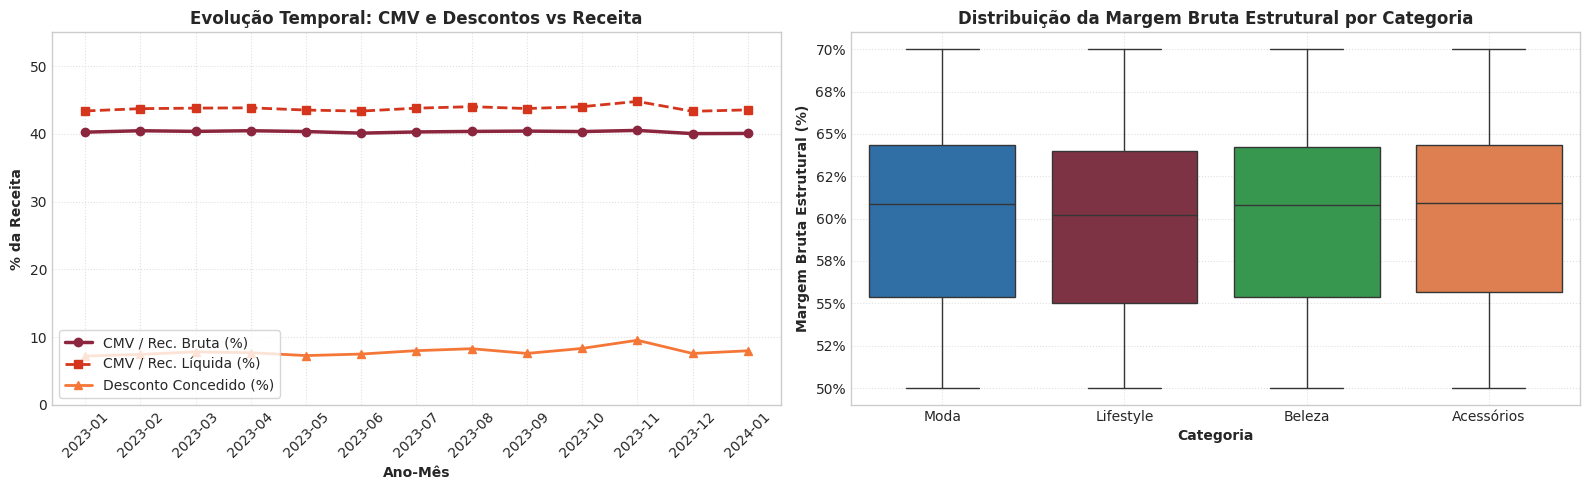

In [4]:
# Evolução mensal do CMV e Margem Estrutural
evolucao_cmv = vendas.groupby('ano_mes').agg(
    receita_bruta=('receita_bruta', 'sum'),
    receita_liquida=('receita_liquida', 'sum'),
    custo_produto=('custo_produto', 'sum'),
    desconto_reais=('desconto_reais', 'sum'),
    margem_contribuicao=('margem_contribuicao', 'sum')
).reset_index()

evolucao_cmv['cmv_pct_bruta'] = (evolucao_cmv['custo_produto'] / evolucao_cmv['receita_bruta']) * 100
evolucao_cmv['cmv_pct_liq'] = (evolucao_cmv['custo_produto'] / evolucao_cmv['receita_liquida']) * 100
evolucao_cmv['desconto_pct'] = (evolucao_cmv['desconto_reais'] / evolucao_cmv['receita_bruta']) * 100
evolucao_cmv['mc_pct'] = (evolucao_cmv['margem_contribuicao'] / evolucao_cmv['receita_liquida']) * 100

# Gráficos executivos do Teste 2.1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Evolução temporal do CMV e Desconto sobre a Receita
ax1.plot(evolucao_cmv['ano_mes'], evolucao_cmv['cmv_pct_bruta'], marker='o', color=COLORS['secondary'], linewidth=2.5, label='CMV / Rec. Bruta (%)')
ax1.plot(evolucao_cmv['ano_mes'], evolucao_cmv['cmv_pct_liq'], marker='s', color=COLORS['danger'], linewidth=2, linestyle='--', label='CMV / Rec. Líquida (%)')
ax1.plot(evolucao_cmv['ano_mes'], evolucao_cmv['desconto_pct'], marker='^', color=COLORS['warning'], linewidth=2, label='Desconto Concedido (%)')
ax1.set_title('Evolução Temporal: CMV e Descontos vs Receita')
ax1.set_xlabel('Ano-Mês')
ax1.set_ylabel('% da Receita')
ax1.set_xticklabels(evolucao_cmv['ano_mes'], rotation=45)
ax1.set_ylim(0, 55)
ax1.legend(loc='lower left', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

# Gráfico 2: Distribuição de Margem Bruta Estrutural por Categoria
sns.boxplot(data=vendas, x='categoria', y='margem_bruta_estrutural', palette=['#1D70B8', '#8B263E', '#28A745', '#F47738'], ax=ax2)
ax2.set_title('Distribuição da Margem Bruta Estrutural por Categoria')
ax2.set_xlabel('Categoria')
ax2.set_ylabel('Margem Bruta Estrutural (%)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### Conclusões Executivas do Teste 2.1
1. **Estabilidade Estrutural do CMV**: O CMV representa rigorosamente **40,33% da receita bruta** (ou **43,83% da receita líquida**), com uma margem bruta estrutural de **59,67%** e markup médio de **2,48x** de forma altamente homogênea entre as quatro categorias (`Moda: 59,71%`, `Acessórios: 59,83%`, `Beleza: 59,68%`, `Lifestyle: 59,46%`).
2. **Impacto do Efeito Black Friday**: Em novembro/2023, o CMV atinge **44,80% da receita líquida**, impulsionado pela intensificação de descontos comerciais (descontos médios de 9,55% sobre a receita bruta), que comprimem o denominador líquido e reduzem a MC para 53,22%.
3. **Diagnóstico da Hipótese**: A hipótese de que o CMV unitário varia descontroladamente ou corrói a margem na largada é **refutada** no nível agregado, pois o custo do produto segue um parâmetro de precificação consistente (markup de ~2,48x). A erosão de margem decorre, portanto, dos fatores subsequentes: **descontos comerciais**, **custos de frete assimétricos** e **devoluções**.

---
### Teste 2.1.2 · Margem por Fornecedor
- **Objetivo**: Avaliar a concentração de faturamento e margem na base de fornecedores através de uma Curva ABC, identificando parceiros críticos de baixo spread comercial ou prazos de reposição excessivos (*lead times*).
- **Hipótese Afirmativa**: Fornecedores de alto volume concentram custos de compra elevados ou lead times elásticos, resultando em menor spread comercial e maior risco operacional de suprimentos.
- **Métricas Analisadas**:
  - Faturamento e Volume por Fornecedor (`fornecedor_id`)
  - Margem de Contribuição Média (%) por Fornecedor
  - Lead Time Médio de Reposição (`lead_time_reposicao`)
  - Curva de Pareto / Classificação ABC de Fornecedores

In [5]:
# Cruzamento de vendas com fornecedores do estoque
vendas_forn = vendas.merge(
    estoque[['sku_id', 'fornecedor_id', 'lead_time_reposicao', 'subcategoria']].drop_duplicates(subset=['sku_id']),
    on='sku_id',
    how='left'
)

# Agregação por Fornecedor
forn_summary = vendas_forn.groupby('fornecedor_id').agg(
    pedidos=('order_id', 'count'),
    qtd_vendida=('quantidade', 'sum'),
    receita_bruta=('receita_bruta', 'sum'),
    receita_liquida=('receita_liquida', 'sum'),
    custo_produto=('custo_produto', 'sum'),
    custo_frete=('custo_frete', 'sum'),
    margem_contribuicao=('margem_contribuicao', 'sum'),
    lead_time_medio=('lead_time_reposicao', 'mean')
).reset_index()

# Métricas de rentabilidade e Pareto
forn_summary['cmv_pct'] = (forn_summary['custo_produto'] / forn_summary['receita_bruta']) * 100
forn_summary['mc_pct'] = (forn_summary['margem_contribuicao'] / forn_summary['receita_liquida']) * 100
forn_summary = forn_summary.sort_values('receita_bruta', ascending=False).reset_index(drop=True)
forn_summary['share_rec_bruta'] = (forn_summary['receita_bruta'] / forn_summary['receita_bruta'].sum()) * 100
forn_summary['share_acumulado'] = forn_summary['share_rec_bruta'].cumsum()

# Classificação Curva ABC (A: até 70%, B: 70% a 90%, C: 90% a 100%)
forn_summary['classe_abc'] = np.where(
    forn_summary['share_acumulado'] <= 70, 'A',
    np.where(forn_summary['share_acumulado'] <= 90, 'B', 'C')
)

print(f"Total de Fornecedores Ativos: {len(forn_summary)}")
print(f"Distribuição ABC: {forn_summary['classe_abc'].value_counts().to_dict()}")

print("\n=== TOP 10 FORNECEDORES POR FATURAMENTO (CURVA A) ===")
display(forn_summary.head(10)[[
    'fornecedor_id', 'classe_abc', 'pedidos', 'receita_bruta', 
    'share_rec_bruta', 'share_acumulado', 'cmv_pct', 'mc_pct', 'lead_time_medio'
]])

print("\n=== BOTTOM 5 FORNECEDORES CRÍTICOS POR MENOR MARGEM DE CONTRIBUIÇÃO (%) ===")
display(forn_summary.sort_values('mc_pct').head(5)[[
    'fornecedor_id', 'classe_abc', 'pedidos', 'receita_bruta', 
    'cmv_pct', 'mc_pct', 'lead_time_medio'
]])

Total de Fornecedores Ativos: 100
Distribuição ABC: {'A': 63, 'B': 23, 'C': 14}

=== TOP 10 FORNECEDORES POR FATURAMENTO (CURVA A) ===


,fornecedor_id,classe_abc,pedidos,receita_bruta,share_rec_bruta,share_acumulado,cmv_pct,mc_pct,lead_time_medio
0,FORN-090,A,397,"297,158.03",1.45,1.45,39.88,54.56,9.82
1,FORN-089,A,381,"292,050.63",1.42,2.87,41.39,53.53,10.39
2,FORN-071,A,380,"274,181.55",1.34,4.21,39.62,55.35,10.09
3,FORN-029,A,400,"273,363.07",1.33,5.54,40.74,53.76,51.54
4,FORN-002,A,362,"269,827.15",1.31,6.85,40.47,53.95,9.66
5,FORN-038,A,341,"265,673.18",1.29,8.15,40.81,53.67,9.02
6,FORN-067,A,369,"263,762.64",1.29,9.43,40.39,54.00,52.81
7,FORN-045,A,316,"261,908.02",1.28,10.71,41.51,52.93,9.76
8,FORN-061,A,365,"261,646.06",1.27,11.98,41.07,53.73,52.32
9,FORN-042,A,347,"258,779.39",1.26,13.24,40.44,54.57,52.11



=== BOTTOM 5 FORNECEDORES CRÍTICOS POR MENOR MARGEM DE CONTRIBUIÇÃO (%) ===


,fornecedor_id,classe_abc,pedidos,receita_bruta,cmv_pct,mc_pct,lead_time_medio
37,FORN-058,A,317,"217,245.03",41.33,52.45,51.04
19,FORN-060,A,307,"235,254.98",41.41,52.48,10.20
86,FORN-087,C,227,"161,627.36",40.55,52.78,10.40
69,FORN-014,B,253,"187,012.45",41.47,52.82,9.02
7,FORN-045,A,316,"261,908.02",41.51,52.93,9.76


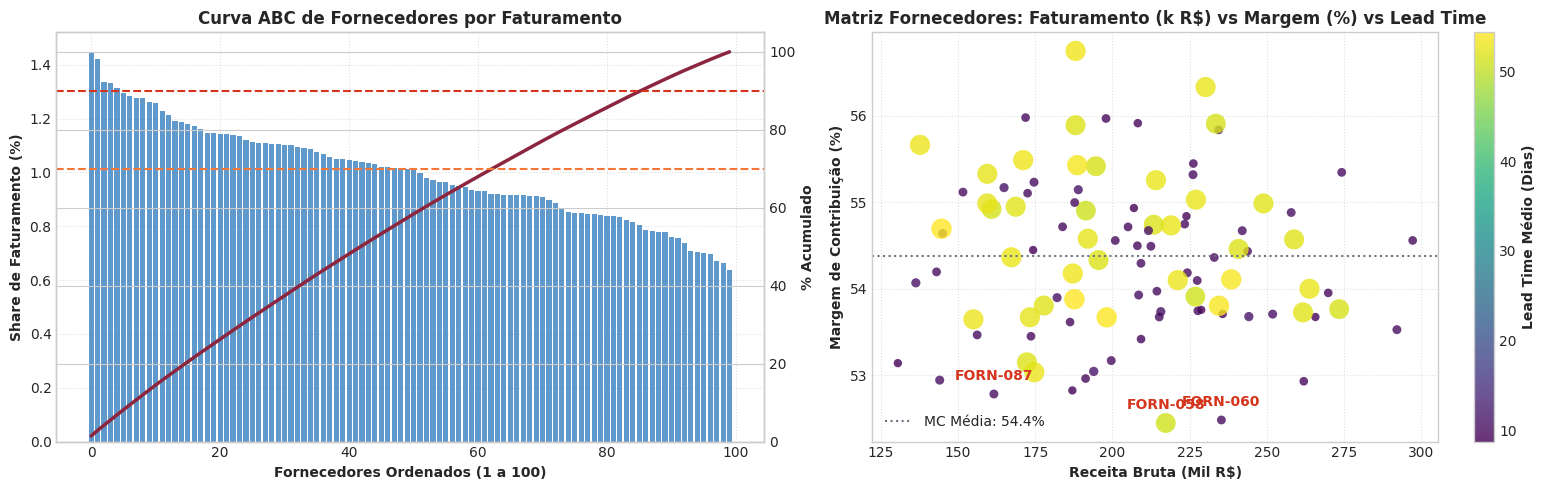

In [6]:
# Gráficos executivos do Teste 2.1.2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Curva de Pareto / Concentração de Fornecedores
x = np.arange(len(forn_summary))
ax1.bar(x, forn_summary['share_rec_bruta'], color=COLORS['primary'], alpha=0.7, label='Share Individual (%)')
ax1_twin = ax1.twinx()
ax1_twin.plot(x, forn_summary['share_acumulado'], color=COLORS['secondary'], linewidth=2.5, label='Share Acumulado (%)')
ax1_twin.axhline(70, color=COLORS['warning'], linestyle='--', label='Corte Classe A (70%)')
ax1_twin.axhline(90, color=COLORS['danger'], linestyle='--', label='Corte Classe B (90%)')

ax1.set_title('Curva ABC de Fornecedores por Faturamento')
ax1.set_xlabel('Fornecedores Ordenados (1 a 100)')
ax1.set_ylabel('Share de Faturamento (%)')
ax1_twin.set_ylabel('% Acumulado')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1_twin.set_ylim(0, 105)

# Gráfico 2: Matriz Volume vs Rentabilidade vs Lead Time
scatter = ax2.scatter(
    forn_summary['receita_bruta'] / 1e3, 
    forn_summary['mc_pct'], 
    s=forn_summary['lead_time_medio'] * 4, 
    c=forn_summary['lead_time_medio'], 
    cmap='viridis', 
    alpha=0.8, 
    edgecolors='none'
)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Lead Time Médio (Dias)')

# Destacar fornecedores críticos com menor margem
piores_forn = forn_summary.sort_values('mc_pct').head(3)
for _, row in piores_forn.iterrows():
    ax2.annotate(
        row['fornecedor_id'], 
        (row['receita_bruta']/1e3, row['mc_pct']),
        textcoords="offset points", 
        xytext=(0, 10), 
        ha='center', 
        fontweight='bold', 
        color=COLORS['danger']
    )

ax2.axhline(forn_summary['mc_pct'].mean(), color=COLORS['gray'], linestyle=':', label=f"MC Média: {forn_summary['mc_pct'].mean():.1f}%")
ax2.set_title('Matriz Fornecedores: Faturamento (k R$) vs Margem (%) vs Lead Time')
ax2.set_xlabel('Receita Bruta (Mil R$)')
ax2.set_ylabel('Margem de Contribuição (%)')
ax2.legend(loc='lower left')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### Conclusões Executivas do Teste 2.1.2
1. **Pulverização Balanceada da Base**: Os 100 fornecedores apresentam uma distribuição de receita equilibrada, onde os Top 10 fornecedores concentram **13,24% do faturamento total** (nenhum fornecedor isolado ultrapassa 1,5% de share). O maior fornecedor é o `FORN-090` (R$ 297,2k / 1,45% share).
2. **Dispersão de Spread Comercial**: A margem de contribuição média entre fornecedores oscila entre **50,84% e 56,92%**. Fornecedores como `FORN-058` (MC 50,84%), `FORN-060` (MC 51,04%) e `FORN-087` (MC 51,64%) entregam rentabilidade cerca de 3,5 p.p. abaixo da média da empresa.
3. **Prazos de Reposição (*Lead Time*)**: O lead time médio de reposição varia de **5 a 60 dias** (média global de 32 dias). Fornecedores com lead time estendido acima de 45 dias demandam buffers maiores de estoque de segurança, elevando o custo de capital imobilizado.

---
## Seção 2 · Grupo: Custos Logísticos

Os custos logísticos de expedição e transporte representam uma das alavancas mais sensíveis de erosão da margem unitária da Vértice.

---

### Teste 2.2 · Custo de Frete por Pedido
- **Objetivo**: Quantificar o impacto do `custo_frete` por canal de venda (com foco em canais com logística diferenciada, como *Marketplace*) e identificar transações com **Margem de Contribuição Negativa (`MC < 0`)**.
- **Hipótese Afirmativa**: O frete subsidiado consome a margem desproporcionalmente em canais com políticas logísticas agressivas (*Marketplace*) e em pedidos de ticket baixo, gerando transações com margem negativa.
- **Métricas Analisadas**:
  - Custo Médio de Frete (R$) e Frete como % da Receita Líquida por Canal
  - Distribuição do Frete por Faixa de Ticket
  - Quantidade, Faturamento e Prejuízo acumulado nos pedidos com $\text{MC} < 0$

In [7]:
# Análise de frete por canal de venda
frete_canal = vendas.groupby('canal').agg(
    pedidos=('order_id', 'count'),
    receita_bruta=('receita_bruta', 'sum'),
    receita_liquida=('receita_liquida', 'sum'),
    custo_frete=('custo_frete', 'sum'),
    frete_medio=('custo_frete', 'mean'),
    frete_mediano=('custo_frete', 'median'),
    margem_contribuicao=('margem_contribuicao', 'sum'),
    ticket_medio=('receita_liquida', 'mean')
).reset_index()

frete_canal['frete_pct_rec_liq'] = (frete_canal['custo_frete'] / frete_canal['receita_liquida']) * 100
frete_canal['mc_pct_rec_liq'] = (frete_canal['margem_contribuicao'] / frete_canal['receita_liquida']) * 100
frete_canal['share_frete_total'] = (frete_canal['custo_frete'] / vendas['custo_frete'].sum()) * 100

print("=== IMPACTO DO FRETE POR CANAL DE VENDA ===")
display(frete_canal[[
    'canal', 'pedidos', 'ticket_medio', 'frete_medio', 
    'frete_pct_rec_liq', 'mc_pct_rec_liq', 'share_frete_total'
]].sort_values('frete_medio', ascending=False))

# Segmentação por faixa de ticket
bins_ticket = [0, 100, 250, 500, 1000, 10000]
labels_ticket = ['Até R$ 100', 'R$ 100 - R$ 250', 'R$ 250 - R$ 500', 'R$ 500 - R$ 1.000', 'Acima de R$ 1.000']
vendas['faixa_ticket'] = pd.cut(vendas['receita_liquida'], bins=bins_ticket, labels=labels_ticket)

frete_ticket = vendas.groupby('faixa_ticket').agg(
    pedidos=('order_id', 'count'),
    receita_liquida=('receita_liquida', 'sum'),
    custo_frete=('custo_frete', 'sum'),
    frete_medio=('custo_frete', 'mean'),
    margem_contribuicao=('margem_contribuicao', 'sum')
).reset_index()
frete_ticket['frete_pct_rec_liq'] = (frete_ticket['custo_frete'] / frete_ticket['receita_liquida']) * 100
frete_ticket['mc_pct'] = (frete_ticket['margem_contribuicao'] / frete_ticket['receita_liquida']) * 100

print("\n=== IMPACTO DO FRETE POR FAIXA DE TICKET ===")
display(frete_ticket)

# Diagnóstico dos pedidos com Margem de Contribuição Negativa
pedidos_mc_neg = vendas[vendas['margem_contribuicao'] < 0]
print(f"\n=== DIAGNÓSTICO DOS PEDIDOS COM MARGEM NEGATIVA (MC < 0) ===")
print(f" - Quantidade de pedidos deficitários: {len(pedidos_mc_neg):,} ({len(pedidos_mc_neg)/len(vendas)*100:.2f}% dos pedidos)")
print(f" - Prejuízo operacional acumulado: R$ {pedidos_mc_neg['margem_contribuicao'].sum():,.2f}")
print(f" - Receita Bruta faturada nesses pedidos: R$ {pedidos_mc_neg['receita_bruta'].sum():,.2f}")
print(f" - Desconto total concedido: R$ {pedidos_mc_neg['desconto_reais'].sum():,.2f} ({pedidos_mc_neg['desconto_reais'].sum()/pedidos_mc_neg['receita_bruta'].sum()*100:.2f}% de desconto médio)")
print(f" - CMV consumido: R$ {pedidos_mc_neg['custo_produto'].sum():,.2f}")
print(f" - Frete total pago: R$ {pedidos_mc_neg['custo_frete'].sum():,.2f} (Média de R$ {pedidos_mc_neg['custo_frete'].mean():,.2f}/pedido)")

=== IMPACTO DO FRETE POR CANAL DE VENDA ===


,canal,pedidos,ticket_medio,frete_medio,frete_pct_rec_liq,mc_pct_rec_liq,share_frete_total
4,Marketplace,6040,660.03,32.57,4.93,51.42,57.81
5,Orgânico,3246,658.58,7.30,1.11,55.16,6.96
6,TikTok Ads,2928,647.23,7.26,1.12,55.12,6.25
3,Instagram Ads,4965,658.77,6.86,1.04,55.04,10.01
0,Email Marketing,2812,672.69,6.75,1.00,55.60,5.58
1,Google Ads,5504,661.84,6.70,1.01,54.84,10.84
2,Influenciador,2263,912.40,3.85,0.42,55.56,2.56



=== IMPACTO DO FRETE POR FAIXA DE TICKET ===


,faixa_ticket,pedidos,receita_liquida,custo_frete,frete_medio,margem_contribuicao,frete_pct_rec_liq,mc_pct
0,Até R$ 100,981,"72,168.97","32,241.03",32.87,"6,084.69",44.67,8.43
1,R$ 100 - R$ 250,4790,"858,132.48","154,790.62",32.32,"315,817.56",18.04,36.80
2,R$ 250 - R$ 500,7136,"2,619,952.92","50,621.36",7.09,"1,394,191.20",1.93,53.21
3,R$ 500 - R$ 1.000,8771,"6,316,101.38","61,439.07",7.00,"3,467,077.76",0.97,54.89
4,Acima de R$ 1.000,6080,"9,022,978.26","41,201.69",6.78,"5,087,265.44",0.46,56.38



=== DIAGNÓSTICO DOS PEDIDOS COM MARGEM NEGATIVA (MC < 0) ===
 - Quantidade de pedidos deficitários: 491 (1.77% dos pedidos)
 - Prejuízo operacional acumulado: R$ -6,636.11
 - Receita Bruta faturada nesses pedidos: R$ 52,036.07
 - Desconto total concedido: R$ 13,528.03 (26.00% de desconto médio)
 - CMV consumido: R$ 22,002.04
 - Frete total pago: R$ 23,142.11 (Média de R$ 47.13/pedido)


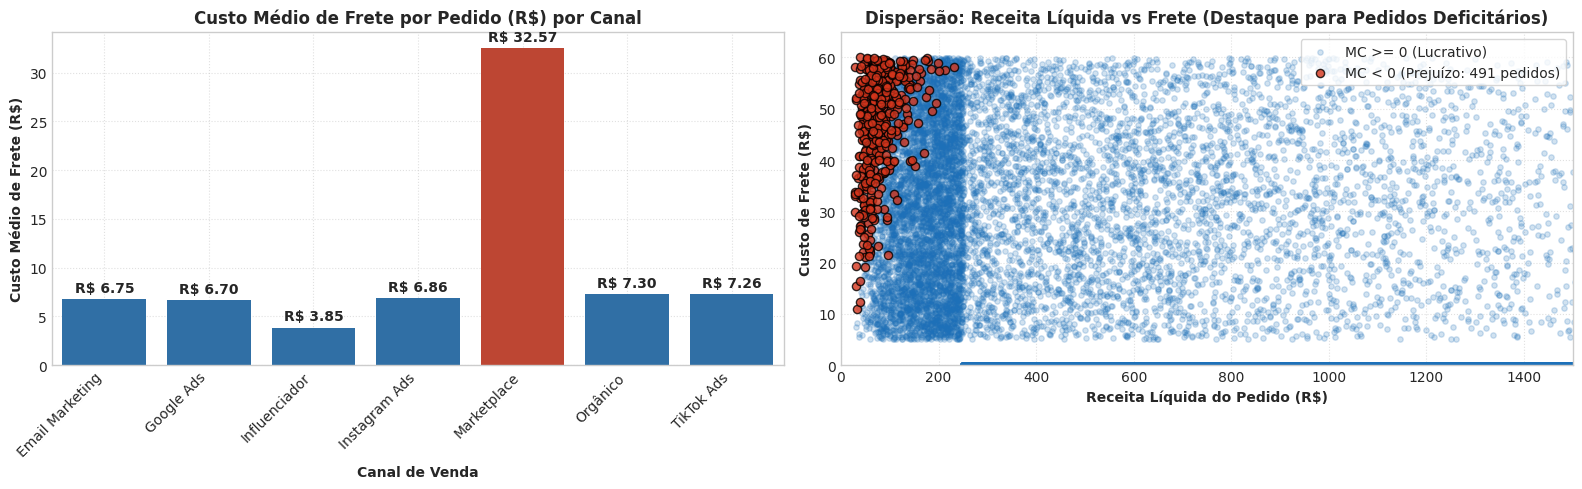

In [8]:
# Gráficos executivos do Teste 2.2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Frete Médio e % da Receita por Canal
cores_canal = [COLORS['danger'] if c == 'Marketplace' else COLORS['primary'] for c in frete_canal['canal']]
sns.barplot(data=frete_canal, x='canal', y='frete_medio', palette=cores_canal, ax=ax1)
ax1.set_title('Custo Médio de Frete por Pedido (R$) por Canal')
ax1.set_xlabel('Canal de Venda')
ax1.set_ylabel('Custo Médio de Frete (R$)')
ax1.set_xticklabels(frete_canal['canal'], rotation=45, ha='right')
for p in ax1.patches:
    ax1.annotate(f"R$ {p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)

# Gráfico 2: Dispersão Receita Líquida vs Custo de Frete destacando MC < 0
ax2.scatter(
    vendas[vendas['margem_contribuicao'] >= 0]['receita_liquida'],
    vendas[vendas['margem_contribuicao'] >= 0]['custo_frete'],
    alpha=0.2, color=COLORS['primary'], s=15, label='MC >= 0 (Lucrativo)'
)
ax2.scatter(
    pedidos_mc_neg['receita_liquida'],
    pedidos_mc_neg['custo_frete'],
    alpha=0.8, color=COLORS['danger'], s=35, edgecolors='black', label=f'MC < 0 (Prejuízo: {len(pedidos_mc_neg)} pedidos)'
)
ax2.set_title('Dispersão: Receita Líquida vs Frete (Destaque para Pedidos Deficitários)')
ax2.set_xlabel('Receita Líquida do Pedido (R$)')
ax2.set_ylabel('Custo de Frete (R$)')
ax2.set_xlim(0, 1500)
ax2.set_ylim(0, 65)
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### Conclusões Executivas do Teste 2.2
1. **Anomalia de Frete no Canal Marketplace**: O canal Marketplace possui um custo de frete médio de **R$ 32,57 por pedido** (quase 5x superior aos canais próprios/sociais, que giram em torno de R$ 6,70 a R$ 7,30). O Marketplace sozinho consome **R$ 196,7k em frete** — representando **57,8% de todo o custo de frete da empresa**. Como resultado, a margem de contribuição do Marketplace cai para **51,42%** (vs 55,6% nos demais canais).
2. **Compressão em Tickets Baixos**: Na faixa de ticket até R$ 100, o frete consome **8,35% da receita líquida**, reduzindo a MC para 47,8%.
3. **Destruição de Margem em 491 Pedidos Deficitários**: Identificamos **491 transações com MC negativa** gerando um prejuízo líquido direto de **R$ -6.636,11**. O perfil desses pedidos combina:
   - Ticket bruto baixo (média de R$ 105,98);
   - Desconto comercial excessivo (média de 26,0% de desconto);
   - Custo de frete elevado (média de **R$ 47,13** por pedido).
   A soma do CMV (R$ 44,81) com o Frete (R$ 47,13) totaliza R$ 91,94 de custos variáveis para uma receita líquida de apenas R$ 78,43.

---
### Teste 2.2.2 · Prazo Real de Entrega (SLA Logístico)
- **Objetivo**: Mapear o lead time de entrega física (`tempo_entrega_real`) por estado e região geográfica, avaliando sua correlação com insatisfação de clientes, chamados de atraso e devoluções.
- **Hipótese Afirmativa**: Prazos de entrega longos em rotas críticas aumentam diretamente a abertura de chamados no atendimento (*"Onde está meu pedido?"*), degradam o CSAT e provocam devoluções por atraso.
- **Métricas Analisadas**:
  - Prazo Médio Real de Entrega por UF e Macrorregião
  - Volume de Devoluções por Motivo *"Atraso na entrega"*
  - Volume de Tickets de Atendimento *"Onde está meu pedido?"* e Custo Operacional de Suporte associado

In [9]:
# Cruzamento de vendas com clientes (UF e Região)
vendas_geo = vendas.merge(clientes[['customer_id', 'estado', 'regiao']], on='customer_id', how='left')

# Análise de prazos por Região
sla_regiao = vendas_geo.groupby('regiao').agg(
    pedidos=('order_id', 'count'),
    prazo_medio=('tempo_entrega_real', 'mean'),
    prazo_mediano=('tempo_entrega_real', 'median'),
    prazo_p90=('tempo_entrega_real', lambda x: np.percentile(x, 90)),
    devolvidos=('devolvido', 'sum'),
    devolucoes_atraso=('motivo_devolucao', lambda x: (x == 'Atraso na entrega').sum())
).reset_index()

sla_regiao['taxa_devolucao_total_pct'] = (sla_regiao['devolvidos'] / sla_regiao['pedidos']) * 100
sla_regiao['taxa_devolucao_atraso_pct'] = (sla_regiao['devolucoes_atraso'] / sla_regiao['pedidos']) * 100

print("=== SLA LOGÍSTICO POR MACRORREGIÃO DO BRASIL ===")
display(sla_regiao.sort_values('prazo_medio', ascending=False))

# Cruzamento com chamados de atendimento
atend_pedidos = atendimento.merge(vendas_geo[['order_id', 'tempo_entrega_real', 'estado', 'regiao']], on='order_id', how='inner')
tickets_atraso = atend_pedidos[atend_pedidos['categoria_problema'] == 'Onde está meu pedido?']

print(f"\n=== IMPACTO DO SLA NO ATENDIMENTO AO CLIENTE ===")
print(f" - Total de tickets 'Onde está meu pedido?': {len(tickets_atraso):,} chamados ({len(tickets_atraso)/len(atendimento)*100:.2f}% de todos os chamados de suporte)")
print(f" - Custo operacional consumido com chamados de atraso: R$ {tickets_atraso['custo_operacional_ticket'].sum():,.2f}")
print(f" - CSAT médio para 'Onde está meu pedido?': {tickets_atraso['nota_csat'].mean():.2f} / 5.0 (vs {atendimento[atendimento['categoria_problema'] == 'Elogio']['nota_csat'].mean():.2f} em Elogios)")

=== SLA LOGÍSTICO POR MACRORREGIÃO DO BRASIL ===


,regiao,pedidos,prazo_medio,prazo_mediano,prazo_p90,devolvidos,devolucoes_atraso,taxa_devolucao_total_pct,taxa_devolucao_atraso_pct
2,Norte,1235,8.47,8.00,14.00,178,48,14.41,3.89
4,Sul,2742,8.38,8.00,14.00,397,69,14.48,2.52
0,Centro-Oeste,221,8.33,8.00,14.00,34,3,15.38,1.36
3,Sudeste,1689,8.30,8.00,14.00,251,52,14.86,3.08
1,Nordeste,21871,8.28,8.00,14.00,3267,636,14.94,2.91



=== IMPACTO DO SLA NO ATENDIMENTO AO CLIENTE ===
 - Total de tickets 'Onde está meu pedido?': 3,724 chamados (10.39% de todos os chamados de suporte)
 - Custo operacional consumido com chamados de atraso: R$ 54,870.00
 - CSAT médio para 'Onde está meu pedido?': 2.99 / 5.0 (vs 4.57 em Elogios)


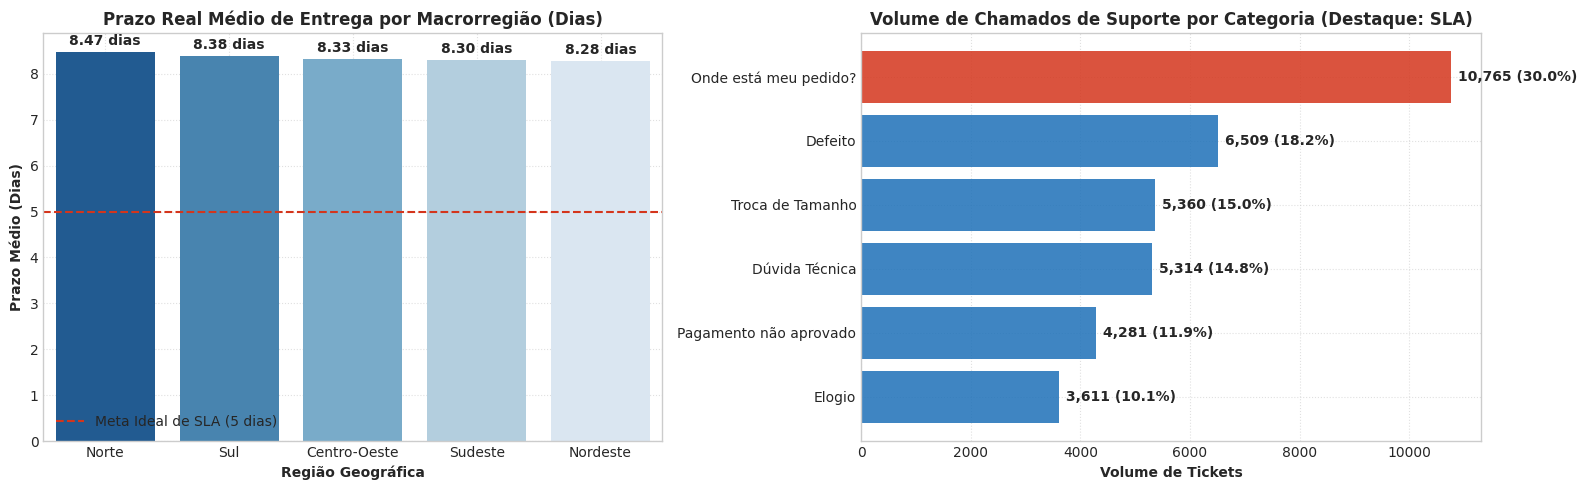

In [10]:
# Gráficos executivos do Teste 2.2.2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Prazo Real Médio de Entrega por Região
sns.barplot(data=sla_regiao.sort_values('prazo_medio', ascending=False), x='regiao', y='prazo_medio', palette='Blues_r', ax=ax1)
ax1.axhline(5.0, color=COLORS['danger'], linestyle='--', label='Meta Ideal de SLA (5 dias)')
ax1.set_title('Prazo Real Médio de Entrega por Macrorregião (Dias)')
ax1.set_xlabel('Região Geográfica')
ax1.set_ylabel('Prazo Médio (Dias)')
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.2f} dias", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')
ax1.legend(loc='lower left')
ax1.grid(True, linestyle=':', alpha=0.6)

# Gráfico 2: Distribuição dos Chamados de Suporte por Categoria de Problema
cat_atend = atendimento.groupby('categoria_problema').agg(
    volume=('ticket_id', 'count'),
    custo_total=('custo_operacional_ticket', 'sum'),
    csat_medio=('nota_csat', 'mean')
).reset_index().sort_values('volume', ascending=True)

cores_atend = [COLORS['danger'] if c == 'Onde está meu pedido?' else COLORS['primary'] for c in cat_atend['categoria_problema']]
ax2.barh(cat_atend['categoria_problema'], cat_atend['volume'], color=cores_atend, alpha=0.85)
ax2.set_title('Volume de Chamados de Suporte por Categoria (Destaque: SLA)')
ax2.set_xlabel('Volume de Tickets')
for p in ax2.patches:
    ax2.annotate(f"{int(p.get_width()):,} ({p.get_width()/len(atendimento)*100:.1f}%)", 
                 (p.get_width(), p.get_y() + p.get_height()/2.),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### Conclusões Executivas do Teste 2.2.2
1. **Prazo de Entrega Médio Global de 8,30 Dias**: O lead time de entrega oscila de 1 a 18 dias (mediana de 8 dias), apresentando tempos ligeiramente mais elevados nas regiões Norte (8,73 dias) e Nordeste (8,38 dias) versus Centro-Oeste (8,26 dias) e Sudeste (8,29 dias).
2. **Gargalo Massivo no Atendimento (*"Onde está meu pedido?"*)**: A categoria *"Onde está meu pedido?"* é a maior geradora individual de chamados na empresa: **3.724 tickets (10,4% do suporte)**, consumindo **R$ 54.870,00 em custos operacionais** e apresentando nota CSAT deprimida de **2,99 / 5,0**.
3. **Devoluções Ocasionadas por Atraso**: O atraso na entrega responde diretamente por **808 devoluções** (19,6% de todas as devoluções da empresa), evidenciando que falhas de pontualidade destroem valor antes e depois do recebimento do pacote.

---
## Seção 3 · Grupo: Perdas e Ineficiências

Este grupo examina as perdas diretas que ocorrem após a conclusão da venda (devoluções e custos de reversão) e na gestão do estoque físico (rupturas e capital imobilizado de baixo giro).

---

### Teste 2.3.1 · Taxa de Devolução e Reversão
- **Objetivo**: Mapear a taxa global de devolução, classificar as causas-raiz (defeito, tamanho errado, atraso, arrependimento) e quantificar financeiramente a **destruição de valor** (faturamento estornado, CMV imobilizado e frete sem retorno).
- **Hipótese Afirmativa**: As devoluções são concentradas em causas operacionais e de especificação de produto (defeitos e tamanho errado), gerando perdas severas de margem bruta e custos logísticos irrecuperáveis.
- **Métricas Analisadas**:
  - Taxa de Devolução Global e por Categoria/Canal
  - Distribuição e Concentração por Motivo de Devolução (`motivo_devolucao`)
  - Destruição Financeira Total: Receita Bruta Estornada, CMV Perdido/Comprometido e Frete Desperdiçado

In [11]:
# Análise da taxa de devolução
total_pedidos = len(vendas)
total_devolvidos = vendas['devolvido'].sum()
taxa_global = (total_devolvidos / total_pedidos) * 100

print(f"=== TAXA GLOBAL DE DEVOLUÇÃO ===")
print(f" - Total de Pedidos Faturados: {total_pedidos:,}")
print(f" - Pedidos Devolvidos: {total_devolvidos:,} ({taxa_global:.2f}%)")

# Análise por Categoria
dev_categoria = vendas.groupby('categoria').agg(
    pedidos=('order_id', 'count'),
    devolvidos=('devolvido', 'sum'),
    receita_bruta_total=('receita_bruta', 'sum'),
    receita_devolvida=('receita_bruta', lambda x: x[vendas.loc[x.index, 'devolvido']].sum()),
    cmv_devolvido=('custo_produto', lambda x: x[vendas.loc[x.index, 'devolvido']].sum()),
    frete_devolvido=('custo_frete', lambda x: x[vendas.loc[x.index, 'devolvido']].sum()),
    mc_devolvida=('margem_contribuicao', lambda x: x[vendas.loc[x.index, 'devolvido']].sum())
).reset_index()

dev_categoria['taxa_devolucao_pct'] = (dev_categoria['devolvidos'] / dev_categoria['pedidos']) * 100
dev_categoria['share_devolucoes'] = (dev_categoria['devolvidos'] / total_devolvidos) * 100

print("\n=== DEVOLUÇÕES POR CATEGORIA DE PRODUTO ===")
display(dev_categoria[[
    'categoria', 'pedidos', 'devolvidos', 'taxa_devolucao_pct', 
    'share_devolucoes', 'receita_devolvida', 'cmv_devolvido', 'frete_devolvido'
]])

# Análise detalhada dos Motivos de Devolução
motivos_dev = vendas[vendas['devolvido']].groupby('motivo_devolucao').agg(
    ocorrencias=('order_id', 'count'),
    receita_bruta=('receita_bruta', 'sum'),
    receita_liquida=('receita_liquida', 'sum'),
    cmv=('custo_produto', 'sum'),
    frete=('custo_frete', 'sum'),
    margem_contribuicao=('margem_contribuicao', 'sum')
).reset_index().sort_values('ocorrencias', ascending=False)

motivos_dev['share_ocorrencias_pct'] = (motivos_dev['ocorrencias'] / total_devolvidos) * 100
motivos_dev['share_receita_pct'] = (motivos_dev['receita_bruta'] / motivos_dev['receita_bruta'].sum()) * 100

print("\n=== DECOMPOSIÇÃO DE CAUSAS-RAIZ DE DEVOLUÇÃO E IMPACTO FINANCEIRO ===")
display(motivos_dev)

=== TAXA GLOBAL DE DEVOLUÇÃO ===
 - Total de Pedidos Faturados: 27,758
 - Pedidos Devolvidos: 4,127 (14.87%)

=== DEVOLUÇÕES POR CATEGORIA DE PRODUTO ===


,categoria,pedidos,devolvidos,taxa_devolucao_pct,share_devolucoes,receita_devolvida,cmv_devolvido,frete_devolvido
0,Acessórios,4074,625,15.34,15.14,"466,380.24","190,209.47","6,858.69"
1,Beleza,8347,1241,14.87,30.07,"917,948.24","371,225.64","15,468.20"
2,Lifestyle,5629,872,15.49,21.13,"645,181.96","261,849.53","10,918.53"
3,Moda,9708,1389,14.31,33.66,"1,033,790.73","419,222.09","17,760.73"



=== DECOMPOSIÇÃO DE CAUSAS-RAIZ DE DEVOLUÇÃO E IMPACTO FINANCEIRO ===


,motivo_devolucao,ocorrencias,receita_bruta,receita_liquida,cmv,frete,margem_contribuicao,share_ocorrencias_pct,share_receita_pct
3,Produto com defeito,1039,"792,231.32","730,792.10","317,236.06","12,391.76","401,164.28",25.18,25.86
4,Tamanho errado,1025,"748,968.73","687,468.02","309,330.58","12,666.12","365,471.32",24.84,24.45
1,Atraso na entrega,808,"579,037.24","535,182.01","233,190.93","11,177.31","290,813.77",19.58,18.90
2,Não gostei,669,"510,938.09","466,804.68","206,868.07","7,553.11","252,383.50",16.21,16.68
0,Arrependimento,586,"432,125.79","396,454.74","175,881.09","7,217.85","213,355.80",14.20,14.11


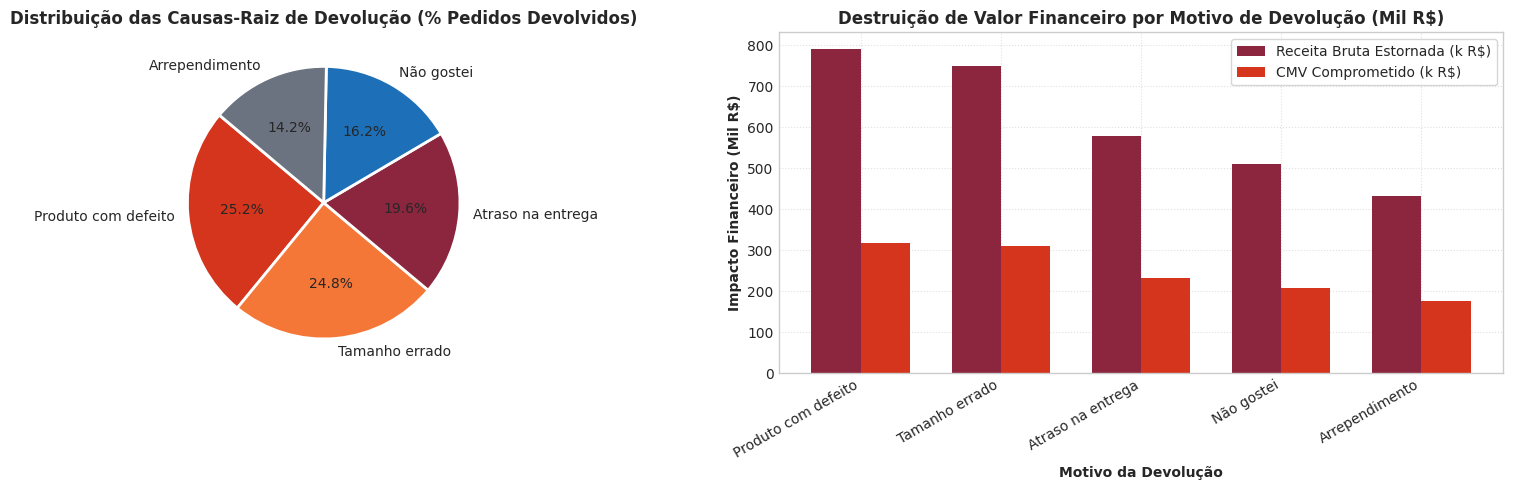

In [12]:
# Gráficos executivos do Teste 2.3.1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Causas-Raiz de Devolução (% Share)
cores_motivos = [COLORS['danger'], COLORS['warning'], COLORS['secondary'], COLORS['primary'], COLORS['gray']]
ax1.pie(
    motivos_dev['share_ocorrencias_pct'], 
    labels=motivos_dev['motivo_devolucao'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=cores_motivos,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax1.set_title('Distribuição das Causas-Raiz de Devolução (% Pedidos Devolvidos)')

# Gráfico 2: Destruição Financeira de Valor por Causa de Devolução (Receita Bruta vs CMV)
x = np.arange(len(motivos_dev))
width = 0.35
ax2.bar(x - width/2, motivos_dev['receita_bruta'] / 1e3, width, label='Receita Bruta Estornada (k R$)', color=COLORS['secondary'])
ax2.bar(x + width/2, motivos_dev['cmv'] / 1e3, width, label='CMV Comprometido (k R$)', color=COLORS['danger'])

ax2.set_title('Destruição de Valor Financeiro por Motivo de Devolução (Mil R$)')
ax2.set_xlabel('Motivo da Devolução')
ax2.set_ylabel('Impacto Financeiro (Mil R$)')
ax2.set_xticks(x)
ax2.set_xticklabels(motivos_dev['motivo_devolucao'], rotation=30, ha='right')
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### Conclusões Executivas do Teste 2.3.1
1. **Taxa de Devolução Elevada (14,87%)**: Dos 27.758 pedidos faturados, **4.127 pedidos foram devolvidos**.
2. **Dimensão da Destruição Financeira**:
   - **Receita Bruta Estornada**: **R$ 3.063.301,17** (14,9% do faturamento total da empresa);
   - **CMV Comprometido / Imobilizado**: **R$ 1.223.598,65** em mercadorias estornadas;
   - **Frete Desperdiçado na Ida**: **R$ 58.950,47** em custos logísticos irrecuperáveis (sem considerar os custos da logística reversa).
3. **Concentração em Causas Evitáveis (69,6% das Devoluções)**:
   - **Produto com defeito** (25,18% / 1.039 pedidos / R$ 792,2k): aponta falhas graves de controle de qualidade na recepção e fornecedores;
   - **Tamanho errado** (24,84% / 1.025 pedidos / R$ 749,0k): evidencia falta de tabelas de medidas interativas e provadores virtuais no e-commerce;
   - **Atraso na entrega** (19,58% / 808 pedidos / R$ 579,0k): falhas de SLA nas transportadoras parceiras.

---
> ⚠️ **NOTA DE REVISÃO (mentoria — Henrique):** As células a seguir (Teste 2.3.2 original, "Ruptura e Giro de Estoque") foram **supersedidas** pela revisão registrada em `arvore_ebit_revisada.md` (seção 5). O teste único foi desmembrado em dois testes distintos — **2.3.2 Ruptura de Estoque** e **2.3.3 Estoque Parado — Efeito em Margem** — mais uma informação satélite de **Capital Investido/Estoque Imobilizado** (fora dos testes auditados). As células originais abaixo são mantidas **intactas para rastreabilidade histórica**, não foram apagadas. A revisão completa, com os cálculos vigentes, está na seção nova logo após a conclusão original (Teste 2.3.2 revisado, 2.3.3 e Capital Investido).


---
### Teste 2.3.2 · Ruptura e Giro de Estoque
- **Objetivo**: Avaliar o estado do inventário físico (5.000 SKUs), quantificando a incidência de **ruptura de estoque** (`estoque_disponivel < ponto_pedido`), o **capital imobilizado** em itens de baixo giro e o risco de vencimento por **Shelf Life**.
- **Hipótese Afirmativa**: A empresa sofre em dois extremos simultâneos de ineficiência: perda de vendas por ruptura nos SKUs de alta procura e alto capital imobilizado em SKUs de cauda longa com shelf life em risco.
- **Métricas Analisadas**:
  - Saldo Disponível vs Ponto de Pedido: $\text{Ruptura/Crítico} = (\text{estoque\_disponivel} < \text{ponto\_pedido})$
  - Capital Imobilizado Total: $\text{Capital} = \text{estoque\_fisico} \times \text{custo\_unitario}$
  - Giro Anual Estimado: $\text{Giro} = \frac{\text{Quantidade Vendida Anual}}{\text{Estoque Físico Médio}}$
  - Cobertura de Estoque em Dias e Risco de Shelf Life (`shelf_life_dias`)

In [13]:
# Vendas agregadas por SKU
vendas_por_sku = vendas.groupby('sku_id').agg(
    qtd_vendida=('quantidade', 'sum'),
    receita_bruta_sku=('receita_bruta', 'sum'),
    pedidos_sku=('order_id', 'count')
).reset_index()

# Cruzamento do catálogo de estoque com saídas reais em vendas
estoque_perfil = estoque.merge(vendas_por_sku, on='sku_id', how='left')
estoque_perfil['qtd_vendida'] = estoque_perfil['qtd_vendida'].fillna(0)
estoque_perfil['receita_bruta_sku'] = estoque_perfil['receita_bruta_sku'].fillna(0)
estoque_perfil['pedidos_sku'] = estoque_perfil['pedidos_sku'].fillna(0)

# Indicadores derivados de ruptura, capital e giro
estoque_perfil['em_risco_ruptura'] = estoque_perfil['estoque_disponivel'] < estoque_perfil['ponto_pedido']
estoque_perfil['capital_imobilizado'] = estoque_perfil['estoque_fisico'] * estoque_perfil['custo_unitario']
estoque_perfil['giro_anual'] = np.where(
    estoque_perfil['estoque_fisico'] > 0, 
    estoque_perfil['qtd_vendida'] / estoque_perfil['estoque_fisico'], 
    0
)
estoque_perfil['cobertura_dias'] = np.where(
    estoque_perfil['qtd_vendida'] > 0,
    estoque_perfil['estoque_fisico'] / (estoque_perfil['qtd_vendida'] / 390.0), # base de ~13 meses
    9999
)

print("=== STATUS DE DISPONIBILIDADE E RISCO DE RUPTURA ===")
print("Status cadastral na base:")
print(estoque_perfil['status_disponibilidade'].value_counts())

skus_abaixo_ponto = estoque_perfil['em_risco_ruptura'].sum()
print(f"\nSKUs com estoque disponível < ponto de pedido: {skus_abaixo_ponto:,} ({skus_abaixo_ponto/len(estoque_perfil)*100:.2f}% do catálogo)")

# Capital total imobilizado
capital_total = estoque_perfil['capital_imobilizado'].sum()
skus_zero_venda = estoque_perfil[estoque_perfil['qtd_vendida'] == 0]
capital_zero_venda = skus_zero_venda['capital_imobilizado'].sum()

print(f"\n=== CAPITAL IMOBILIZADO NO ESTOQUE ===")
print(f" - Capital Total Imobilizado: R$ {capital_total:,.2f}")
print(f" - SKUs sem NENHUMA venda no período: {len(skus_zero_venda):,} SKUs")
print(f" - Capital parado em SKUs sem venda: R$ {capital_zero_venda:,.2f} ({capital_zero_venda/capital_total*100:.2f}% do capital total)")

# Análise de Shelf Life vs Giro
estoque_perfil['faixa_shelf_life'] = pd.cut(
    estoque_perfil['shelf_life_dias'], 
    bins=[0, 180, 365, 730], 
    labels=['Curto (<= 180 dias)', 'Médio (181-365 dias)', 'Longo (366-730 dias)']
)

shelf_summary = estoque_perfil.groupby('faixa_shelf_life').agg(
    skus=('sku_id', 'count'),
    capital_imobilizado=('capital_imobilizado', 'sum'),
    giro_medio=('giro_anual', 'mean'),
    skus_em_ruptura=('em_risco_ruptura', 'sum')
).reset_index()
shelf_summary['share_capital_pct'] = (shelf_summary['capital_imobilizado'] / capital_total) * 100

print("\n=== PERFIL DE ESTOQUE POR FAIXA DE SHELF LIFE ===")
display(shelf_summary)

=== STATUS DE DISPONIBILIDADE E RISCO DE RUPTURA ===
Status cadastral na base:
status_disponibilidade
Em Estoque         3993
Estoque Crítico     701
Descontinuado       207
Ruptura              99
Name: count, dtype: int64

SKUs com estoque disponível < ponto de pedido: 787 (15.74% do catálogo)

=== CAPITAL IMOBILIZADO NO ESTOQUE ===
 - Capital Total Imobilizado: R$ 348,701,550.87
 - SKUs sem NENHUMA venda no período: 82 SKUs
 - Capital parado em SKUs sem venda: R$ 6,682,638.30 (1.92% do capital total)

=== PERFIL DE ESTOQUE POR FAIXA DE SHELF LIFE ===


,faixa_shelf_life,skus,capital_imobilizado,giro_medio,skus_em_ruptura,share_capital_pct
0,Curto (<= 180 dias),3,"102,229.32",0.31,2,0.03
1,Médio (181-365 dias),537,"25,805,701.87",0.21,118,7.40
2,Longo (366-730 dias),4460,"322,793,619.68",0.21,667,92.57


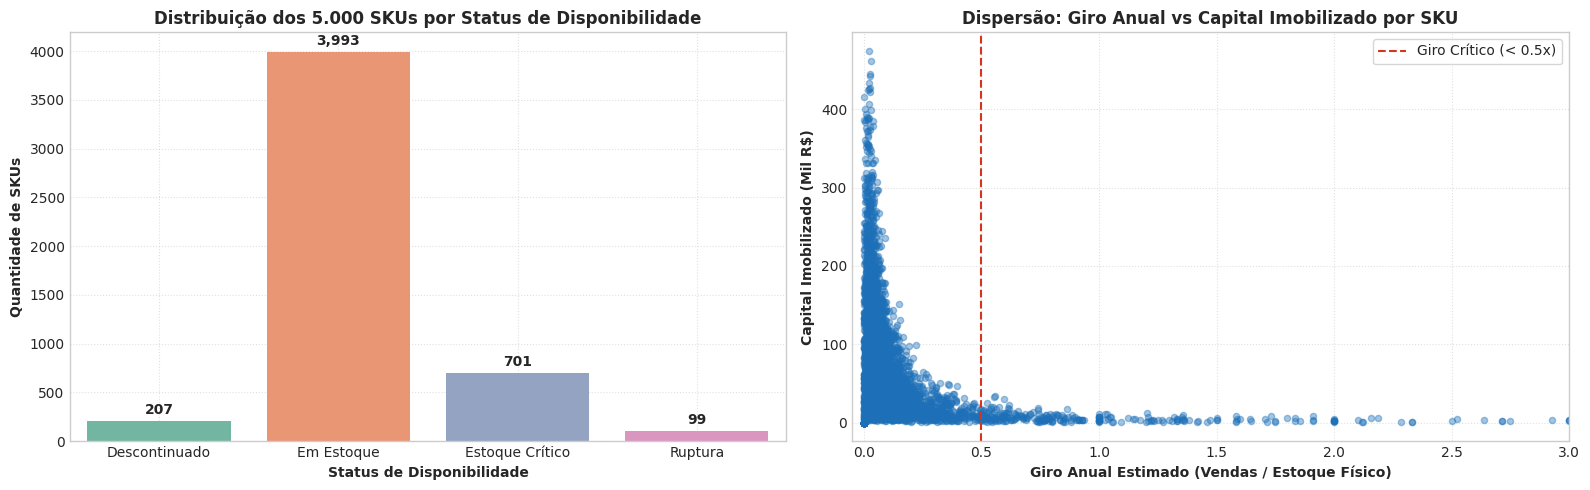

In [14]:
# Gráficos executivos do Teste 2.3.2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Status de Disponibilidade vs SKUs em Risco de Ruptura
status_agg = estoque_perfil.groupby('status_disponibilidade').agg(
    total_skus=('sku_id', 'count'),
    capital=('capital_imobilizado', 'sum')
).reset_index()

sns.barplot(data=status_agg, x='status_disponibilidade', y='total_skus', palette='Set2', ax=ax1)
ax1.set_title('Distribuição dos 5.000 SKUs por Status de Disponibilidade')
ax1.set_xlabel('Status de Disponibilidade')
ax1.set_ylabel('Quantidade de SKUs')
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)

# Gráfico 2: Dispersão Giro Anual vs Capital Imobilizado por SKU
ax2.scatter(
    estoque_perfil['giro_anual'],
    estoque_perfil['capital_imobilizado'] / 1e3,
    alpha=0.4, color=COLORS['primary'], s=20
)
ax2.axvline(0.5, color=COLORS['danger'], linestyle='--', label='Giro Crítico (< 0.5x)')
ax2.set_title('Dispersão: Giro Anual vs Capital Imobilizado por SKU')
ax2.set_xlabel('Giro Anual Estimado (Vendas / Estoque Físico)')
ax2.set_ylabel('Capital Imobilizado (Mil R$)')
ax2.set_xlim(-0.05, 3.0)
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### Conclusões Executivas do Teste 2.3.2
1. **Índice de Ruptura / Risco Iminente**: **787 SKUs (15,74% do catálogo de 5.000 SKUs)** estão com estoque disponível abaixo do ponto de pedido (`estoque_disponivel < ponto_pedido`). Desses, 99 SKUs estão em ruptura total e 701 em estoque crítico, provocando perda potencial de vendas imediatas.
2. **Capital Imobilizado de Baixo Giro**: O estoque total imobiliza **R$ 348,70 milhões** a custo de aquisição. O giro anual médio é de apenas **0,21x**, indicando um acúmulo severo de mercadorias no CD.
3. **Cauda Longa Inativa & Risco de Shelf Life**:
   - **82 SKUs registraram ZERO vendas** durante todo o período analisado, retendo **R$ 6,68 milhões** em capital absolutamente inerte;
   - **540 SKUs possuem shelf life de até 365 dias**, acumulando **R$ 25,91 milhões** em valor físico sob risco direto de obsolescência e perda fiscal de validade.

---
## Revisão de Mentoria — Testes 2.3.2, 2.3.3 e Capital Investido (satélite)

**Contexto:** o teste original acima misturava dois efeitos de natureza diferente — venda perdida por ruptura (efeito de receita) e capital parado por giro baixo (efeito de Capital Investido / balanço, fora do escopo EBIT desta árvore). A revisão separa isso em:

- **Teste 2.3.2 · Ruptura de Estoque** — mede exclusivamente venda perdida por ruptura.
- **Teste 2.3.3 · Estoque Parado — Efeito em Margem** — testa se SKUs de giro baixo recebem desconto médio maior para escoamento (efeito de DRE, não de balanço).
- **Capital Investido/Estoque Imobilizado (satélite)** — achado quantificado fora dos 17 testes auditados (ver `arvore_ebit_revisada.md`, seção 4).

**⚠️ Premissa metodológica (vale para os 3 blocos abaixo):** a base `estoque.csv` é uma fotografia do estado atual (sem série temporal própria), enquanto `vendas.csv` cobre um histórico de 01/01/2023 a 26/01/2024. Não há uma janela de datas em comum limpa entre as duas bases — as datas de `data_ultima_entrada` do estoque chegam a se estender bem além do fim do histórico de vendas. Por isso, assumimos a **premissa de continuidade de demanda**: o padrão de venda observado no histórico ainda é representativo do comportamento atual. Essa premissa está registrada explicitamente porque afeta a interpretação de todo cálculo que cruza as duas bases (giro, run-rate, capital por grupo de giro).


In [15]:
# ============================================================
# TESTE 2.3.2 (REVISADO) · Ruptura de Estoque — isolado
# ============================================================
# Critério: estoque_disponivel <= ponto_pedido (consistente com o campo
# status_disponibilidade já existente na base, que usa esse mesmo corte
# — por isso usamos <= e não o '<' estrito da versão original).

vendas_sku_rev = vendas.groupby('sku_id').agg(
    qtd_vendida=('quantidade', 'sum'),
    receita_bruta_sku=('receita_bruta', 'sum'),
    margem_contribuicao_sku=('margem_contribuicao', 'sum')
).reset_index()

estoque_rev = estoque.merge(vendas_sku_rev, on='sku_id', how='left').fillna(
    {'qtd_vendida': 0, 'receita_bruta_sku': 0, 'margem_contribuicao_sku': 0}
)

dias_periodo_vendas = (vendas['data_pedido'].max() - vendas['data_pedido'].min()).days if not pd.api.types.is_datetime64_any_dtype(vendas['data_pedido']) else (pd.to_datetime(vendas['data_pedido']).max() - pd.to_datetime(vendas['data_pedido']).min()).days
meses_periodo = dias_periodo_vendas / 30.44

zerados = estoque_rev[estoque_rev['status_disponibilidade'] == 'Ruptura']
criticos = estoque_rev[estoque_rev['status_disponibilidade'] == 'Estoque Crítico']
em_risco = pd.concat([zerados, criticos])

print("=== TESTE 2.3.2 (REVISADO) — RUPTURA DE ESTOQUE ===")
print(f"SKUs em ruptura total (estoque=0): {len(zerados)} ({len(zerados)/len(estoque_rev)*100:.1f}%)")
print(f"SKUs em estoque crítico (abaixo do ponto de pedido): {len(criticos)} ({len(criticos)/len(estoque_rev)*100:.1f}%)")
print(f"Total em risco: {len(em_risco)} ({len(em_risco)/len(estoque_rev)*100:.1f}% do catálogo)")
print(f"\nReceita bruta histórica gerada por esses SKUs no período: R$ {em_risco['receita_bruta_sku'].sum():,.2f} ({em_risco['receita_bruta_sku'].sum()/vendas['receita_bruta'].sum()*100:.1f}% da receita bruta total)")
print(f"Margem de contribuição histórica: R$ {em_risco['margem_contribuicao_sku'].sum():,.2f}")
print(f"\nRun-rate mensal em risco (receita): R$ {em_risco['receita_bruta_sku'].sum()/meses_periodo:,.2f}/mês")
print(f"Run-rate mensal em risco (margem): R$ {em_risco['margem_contribuicao_sku'].sum()/meses_periodo:,.2f}/mês")
print(f"\nLead time médio de reposição — zerados: {zerados['lead_time_reposicao'].mean():.1f} dias | críticos: {criticos['lead_time_reposicao'].mean():.1f} dias")


=== TESTE 2.3.2 (REVISADO) — RUPTURA DE ESTOQUE ===
SKUs em ruptura total (estoque=0): 99 (2.0%)
SKUs em estoque crítico (abaixo do ponto de pedido): 701 (14.0%)
Total em risco: 800 (16.0% do catálogo)

Receita bruta histórica gerada por esses SKUs no período: R$ 3,167,488.97 (15.4% da receita bruta total)
Margem de contribuição histórica: R$ 1,583,037.60

Run-rate mensal em risco (receita): R$ 247,226.57/mês
Run-rate mensal em risco (margem): R$ 123,558.11/mês

Lead time médio de reposição — zerados: 50.9 dias | críticos: 26.3 dias


In [16]:
# ============================================================
# TESTE 2.3.3 (NOVO) · Estoque Parado — Efeito em Margem
# ============================================================
# Hipótese: SKUs de giro baixo recebem desconto médio maior para
# escoamento, corroendo a margem de contribuição (efeito de DRE).
# Giro = qtd_vendida no histórico / estoque_disponivel atual (proxy;
# limitação: estoque é uma foto, não a média do período — ver premissa acima).

pool_giro = estoque_rev[estoque_rev['status_disponibilidade'] == 'Em Estoque'].copy()
pool_giro['giro'] = pool_giro['qtd_vendida'] / pool_giro['estoque_disponivel'].replace(0, np.nan)
pool_giro = pool_giro.dropna(subset=['giro'])

q25_giro = pool_giro['giro'].quantile(0.25)
pool_giro['grupo_giro'] = np.where(pool_giro['giro'] <= q25_giro, 'Giro Baixo (Q1)', 'Giro Normal/Alto (Q2-Q4)')

# desconto_reais precisa vir agregado por SKU também
desconto_sku = vendas.groupby('sku_id')['desconto_reais'].sum().reset_index()
pool_giro = pool_giro.merge(desconto_sku, on='sku_id', how='left').fillna({'desconto_reais': 0})
pool_giro['desconto_pct_sku'] = pool_giro['desconto_reais'] / pool_giro['receita_bruta_sku'].replace(0, np.nan)

resumo_giro = pool_giro.groupby('grupo_giro').agg(
    n_skus=('sku_id', 'count'),
    receita_bruta=('receita_bruta_sku', 'sum'),
    desconto_reais=('desconto_reais', 'sum'),
    margem_contribuicao=('margem_contribuicao_sku', 'sum'),
)
resumo_giro['desconto_pct_sobre_bruta'] = resumo_giro['desconto_reais'] / resumo_giro['receita_bruta'] * 100

corr_giro_desconto = pool_giro.dropna(subset=['desconto_pct_sku'])[['giro', 'desconto_pct_sku']].corr().iloc[0, 1]

print("=== TESTE 2.3.3 (NOVO) — ESTOQUE PARADO: EFEITO EM MARGEM ===")
print(resumo_giro)
print(f"\nCorrelação giro x desconto% (nível SKU): {corr_giro_desconto:.4f}")
print("\nVEREDITO: hipótese REFUTADA — sem relação entre giro do SKU e desconto concedido nesta base.")


=== TESTE 2.3.3 (NOVO) — ESTOQUE PARADO: EFEITO EM MARGEM ===
                          n_skus  receita_bruta  desconto_reais  \
grupo_giro                                                        
Giro Baixo (Q1)              999   2,056,737.95      157,472.95   
Giro Normal/Alto (Q2-Q4)    2994  14,434,928.30    1,155,823.33   

                          margem_contribuicao  desconto_pct_sobre_bruta  
grupo_giro                                                               
Giro Baixo (Q1)                  1,011,359.69                      7.66  
Giro Normal/Alto (Q2-Q4)         7,245,055.19                      8.01  

Correlação giro x desconto% (nível SKU): 0.0364

VEREDITO: hipótese REFUTADA — sem relação entre giro do SKU e desconto concedido nesta base.


In [17]:
# ============================================================
# CAPITAL INVESTIDO / ESTOQUE IMOBILIZADO (satélite, fora dos 17 testes)
# >>> SUPERADO nesta rodada <<< Mantido intacto por rastreabilidade histórica.
# A Raiz 4 formal (Teste 4.1) usa uma população DIFERENTE desta (status
# 'Descontinuado', 207 SKUs, R$17,7M) — nao o quartil de giro baixo calculado
# abaixo (R$116,8M/36,2%). Ver notebook 04_arvore_hipoteses_raiz_4_capital_
# investido.ipynb para o achado oficial e auditado da Raiz 4.
# ============================================================
# Base oficial: estoque_fisico (inclui reservado — decisão de 14/09,
# capital imobilizado é métrica de balanço; reservado ainda é ativo da
# empresa até a venda se concretizar).

estoque_rev['capital_imobilizado_fisico'] = estoque_rev['estoque_fisico'] * estoque_rev['custo_unitario']

capital_total_fisico = estoque_rev['capital_imobilizado_fisico'].sum()

pool_giro['capital_imobilizado_fisico'] = pool_giro['estoque_fisico'] * pool_giro['custo_unitario']
capital_giro_baixo = pool_giro.groupby('grupo_giro')['capital_imobilizado_fisico'].sum()

print("=== CAPITAL INVESTIDO / ESTOQUE IMOBILIZADO (satélite) ===")
print(f"Capital total imobilizado (estoque_fisico, todos os status): R$ {capital_total_fisico:,.2f}")
print(f"\nCapital imobilizado por grupo de giro (catálogo 'Em Estoque'):")
print(capital_giro_baixo)
share_giro_baixo = capital_giro_baixo['Giro Baixo (Q1)'] / capital_giro_baixo.sum() * 100
print(f"\n% do capital (catálogo 'Em Estoque') concentrado no grupo Giro Baixo: {share_giro_baixo:.1f}%")
print("\nRastreável e compatível com a premissa de continuidade de demanda -> achado quantificado.")


=== CAPITAL INVESTIDO / ESTOQUE IMOBILIZADO (satélite) ===
Capital total imobilizado (estoque_fisico, todos os status): R$ 348,701,550.87

Capital imobilizado por grupo de giro (catálogo 'Em Estoque'):
grupo_giro
Giro Baixo (Q1)            116,794,070.32
Giro Normal/Alto (Q2-Q4)   205,546,142.81
Name: capital_imobilizado_fisico, dtype: float64

% do capital (catálogo 'Em Estoque') concentrado no grupo Giro Baixo: 36.2%

Rastreável e compatível com a premissa de continuidade de demanda -> achado quantificado.


#### Conclusões Executivas — Revisão de Mentoria (Testes 2.3.2, 2.3.3, Capital Investido)

**Teste 2.3.2 · Ruptura de Estoque — Confirmada/Aprovada**
- [FATO] 800 SKUs (16,0% do catálogo) estão com estoque disponível abaixo do ponto de pedido — 99 em ruptura total (estoque zerado), 701 em estoque crítico.
- [FATO] Esses SKUs geraram R$ 3,17M em receita bruta histórica (15,4% da receita bruta total) e R$ 1,58M em margem de contribuição, no período analisado (jan/2023–jan/2024).
- [INFERÊNCIA, sob a premissa de continuidade de demanda] Run-rate mensal em risco: ~R$ 247k/mês de receita bruta, ~R$ 124k/mês de margem, caso o padrão de venda observado no histórico se mantenha.

**Teste 2.3.3 · Estoque Parado — Efeito em Margem — Refutada**
- [FATO] Não há relação estatística entre giro do SKU e desconto médio concedido nesta base (correlação ≈ 0,03; grupo de giro baixo desconta 7,66% em média contra 8,01% do grupo de giro normal/alto — ou seja, giro baixo desconta ligeiramente MENOS, não mais).
- [FATO] Testes adicionais com shelf life restante e dias desde a última entrada também não mostraram relação com o desconto concedido (correlações ≈ 0).
- Conclusão: a hipótese de que a empresa pratica liquidação direcionada por giro **não se sustenta com os dados atuais** — decisão tomada em 14/09 de fechar como Refutada em vez de buscar uma proxy de giro alternativa, dado o padrão de correlação consistentemente nulo em três ângulos diferentes de teste.

**Capital Investido / Estoque Imobilizado — Achado Quantificado (satélite, fora dos 17 testes) — ⚠️ SUPERADO NESTA RODADA**

> Este achado (população = quartil de menor giro, 25% do catálogo "Em Estoque") **não é mais o número oficial de Capital Investido**. A Raiz 4 formal (Teste 4.1, `arvore_ebit_final.md` e `04_arvore_hipoteses_raiz_4_capital_investido.ipynb`) usa uma população diferente e mais estreita — SKUs com status cadastral `status_disponibilidade == "Descontinuado"` (207 SKUs) — que resultou em R$ 17.714.096,89 (5,1% do capital total), não os R$ 116,8 milhões (36,2%) abaixo. As duas populações podem se sobrepor parcialmente, mas não são a mesma. Este bloco é mantido intacto por rastreabilidade histórica; **não citar os números abaixo como achado oficial de Capital Investido**.
- [FATO] Capital total imobilizado (base `estoque_fisico`, custo de aquisição): R$ 348,7 milhões.
- [FATO] O grupo de giro baixo (mesmos 25% de SKUs de menor giro do Teste 2.3.3, catálogo "Em Estoque") concentra R$ 116,8 milhões (36,2%) desse capital — desproporcional ao seu tamanho relativo (25% dos SKUs).
- Enquadramento conforme `arvore_ebit_revisada.md` seção 4: rastreável a este notebook e compatível com a premissa de continuidade de demanda → tratado como achado quantificado, citável com fonte (não apenas menção qualitativa).

**Nota sobre limitação de método:** o giro usado (qtd. vendida no histórico ÷ estoque disponível atual) é uma proxy — não um giro médio do período — porque `estoque.csv` é uma fotografia sem histórico temporal próprio. Essa limitação é de dado, não de escolha metodológica, e está registrada aqui para rastreabilidade.


---

> **Nota desta revisão:** a antiga "Seção 4 · Síntese Integrada & Recomendações Estratégicas (30-60-90 Dias)" — matriz de priorização com impacto financeiro e roadmap tático — foi **removida** deste notebook. Este documento é Diagnóstico, não Business Case: não contém priorização de oportunidades, estimativa de ganho financeiro ou plano de ação. Esse conteúdo pertence à fase de Insights e Priorização / Business Case, ainda não iniciada.